# F1-RaceIQ-Suite: PCA — Principal Component Analysis


## Step 1 — Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load the Cleaned Dataset



In [2]:
df = pd.read_csv('cleaned_f1_data.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 6939 rows, 19 columns


,Season,Round,Race Name,Date,Circuit,Country,Latitude,Longitude,Driver,Driver Nationality,Driver Age,Constructor,Grid Position,Race Position,Points Earned,Fastest Lap (s),Fastest Lap Rank,Laps Completed,Status
0,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Nino Farina,Italian,44,Alfa Romeo,1,1,9.0,90.239026,-1,70,Finished
1,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Reg Parnell,British,39,Alfa Romeo,4,3,4.0,90.239026,-1,70,Finished
2,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Yves Cabantous,French,46,Talbot-Lago,6,4,3.0,90.239026,-1,68,+2 Laps
3,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Louis Rosier,French,45,Talbot-Lago,9,5,2.0,90.239026,-1,68,+2 Laps
4,1950,1,British Grand Prix,1950-05-13,Silverstone Circuit,UK,52.0786,-1.01694,Bob Gerard,British,36,ERA,13,6,0.0,90.239026,-1,67,+3 Laps


## Step 3 — Identify Numeric Columns



In [3]:
numeric_columns = df.select_dtypes(include=['number']).columns
print("Numeric Columns:", list(numeric_columns))

Numeric Columns: ['Season', 'Round', 'Latitude', 'Longitude', 'Driver Age', 'Grid Position', 'Race Position', 'Points Earned', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']


## Step 4 — Drop Irrelevant Columns



In [4]:
to_drop = ['Latitude', 'Longitude', 'Points Earned', 'Season', 'Round']
df = df.drop(columns=to_drop, errors='ignore')

# Separate target variable for visualisation colouring
target_data = df['Race Position'].copy()

# PCA input — all numeric features except Race Position
pca_data = df.select_dtypes(include=['number']).drop(
    columns=['Race Position'], errors='ignore').copy()

print("PCA input features:", list(pca_data.columns))
print("PCA data shape:", pca_data.shape)
pca_data.head()

PCA input features: ['Driver Age', 'Grid Position', 'Fastest Lap (s)', 'Fastest Lap Rank', 'Laps Completed']
PCA data shape: (6939, 5)


,Driver Age,Grid Position,Fastest Lap (s),Fastest Lap Rank,Laps Completed
0,44,1,90.239026,-1,70
1,39,4,90.239026,-1,70
2,46,6,90.239026,-1,68
3,45,9,90.239026,-1,68
4,36,13,90.239026,-1,67


## Step 5 — Normalise the Data (StandardScaler)



In [5]:
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

pca_data_scaled_df = pd.DataFrame(pca_data_scaled, columns=pca_data.columns)
print("Scaling complete. Sample scaled values:")
pca_data_scaled_df.head()

Scaling complete. Sample scaled values:


,Driver Age,Grid Position,Fastest Lap (s),Fastest Lap Rank,Laps Completed
0,2.630828,-1.492771,0.200131,-0.545025,0.510705
1,1.676452,-1.058398,0.200131,-0.545025,0.510705
2,3.012579,-0.768817,0.200131,-0.545025,0.452375
3,2.821704,-0.334444,0.200131,-0.545025,0.452375
4,1.103826,0.244719,0.200131,-0.545025,0.423210


## Step 6 — 2D PCA (2 Principal Components)



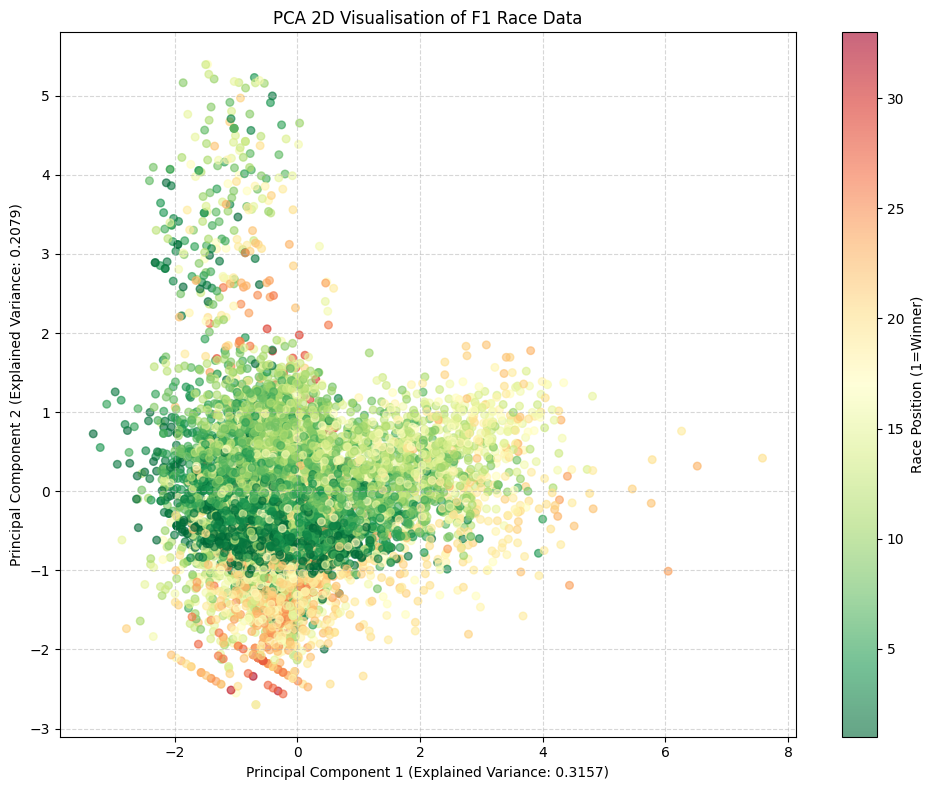

PC1 explains: 31.57% of variance
PC2 explains: 20.79% of variance
Total explained: 52.35%


In [6]:
pca_2d = PCA(n_components=2)
pca_result_2d = pca_2d.fit_transform(pca_data_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_result_2d[:, 0], pca_result_2d[:, 1],
                      c=target_data, cmap='RdYlGn_r',
                      alpha=0.6, s=30)
plt.colorbar(scatter, label='Race Position (1=Winner)')
plt.title('PCA 2D Visualisation of F1 Race Data')
plt.xlabel(f'Principal Component 1 (Explained Variance: {pca_2d.explained_variance_ratio_[0]:.4f})')
plt.ylabel(f'Principal Component 2 (Explained Variance: {pca_2d.explained_variance_ratio_[1]:.4f})')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"Total explained: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

## Step 7 — 3D PCA (3 Principal Components)



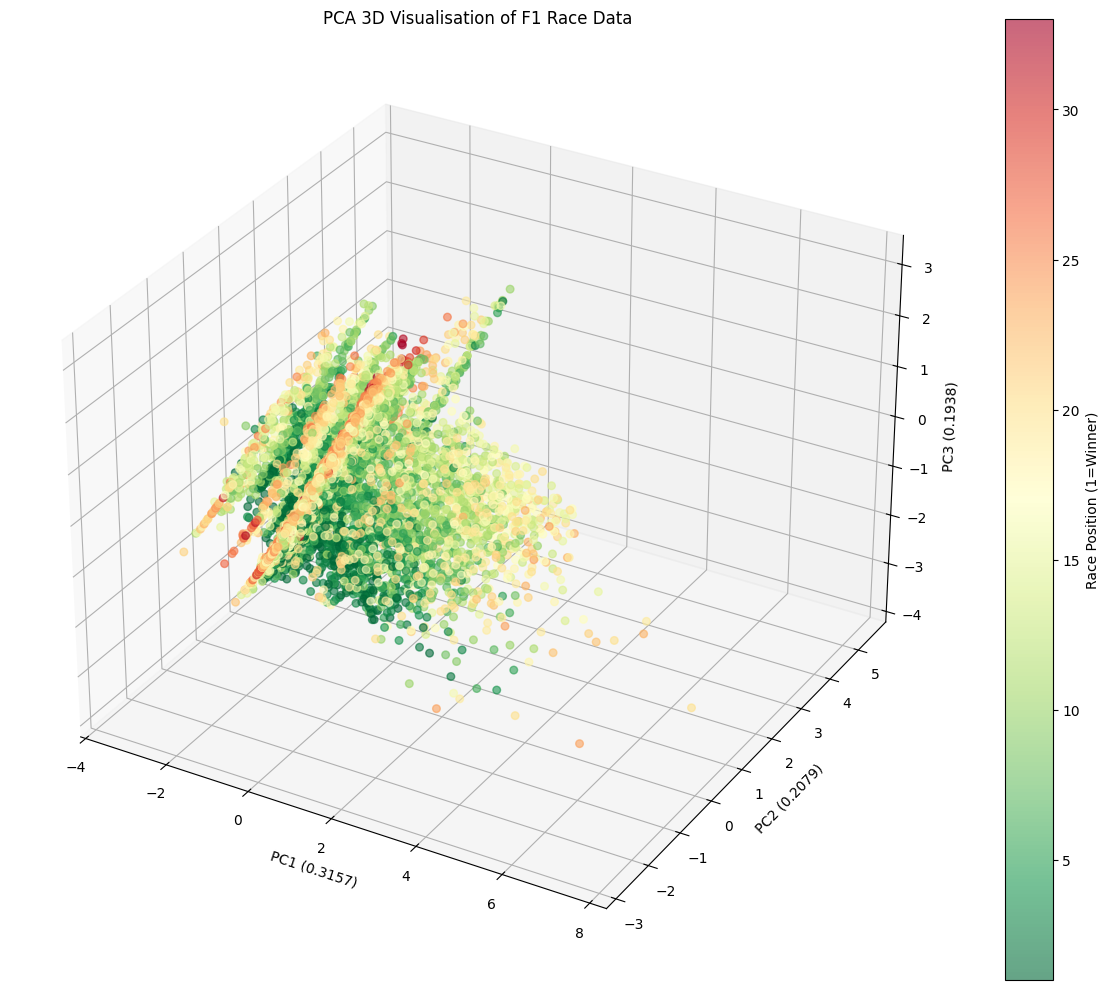

3D PCA result sample:


,PC1,PC2,PC3
0,-1.768219,-0.015888,-2.355693
1,-1.268658,0.054367,-1.615843
2,-1.763651,0.438092,-2.048846
3,-1.588842,0.656287,-1.674508
4,-0.727868,0.641018,-0.465825


In [7]:
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(pca_data_scaled)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_result_3d[:, 0],
                     pca_result_3d[:, 1],
                     pca_result_3d[:, 2],
                     c=target_data, cmap='RdYlGn_r',
                     alpha=0.6, s=30)

ax.set_title('PCA 3D Visualisation of F1 Race Data')
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.4f})')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.4f})')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.4f})')
plt.colorbar(scatter, ax=ax, label='Race Position (1=Winner)')
plt.tight_layout()
plt.show()

pca_result_3d_df = pd.DataFrame(pca_result_3d, columns=['PC1', 'PC2', 'PC3'])
print("3D PCA result sample:")
pca_result_3d_df.head()

## Step 8 — Explained Variance Analysis



In [8]:
explained_variance_2d = np.sum(pca_2d.explained_variance_ratio_) * 100
explained_variance_3d = np.sum(pca_3d.explained_variance_ratio_) * 100

print(f"Information retained in 2D PCA: {explained_variance_2d:.2f}%")
print(f"Individual ratios (2D): {pca_2d.explained_variance_ratio_}")

print(f"\nInformation retained in 3D PCA: {explained_variance_3d:.2f}%")
print(f"Individual ratios (3D): {pca_3d.explained_variance_ratio_}")

Information retained in 2D PCA: 52.35%
Individual ratios (2D): [0.31566867 0.20786159]

Information retained in 3D PCA: 71.73%
Individual ratios (3D): [0.31566867 0.20786159 0.19377718]


## Step 9 — Number of Components for 95% Variance



In [9]:
pca_full = PCA()
pca_full.fit(pca_data_scaled)

cumulative_explained_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components_95 = np.argmax(cumulative_explained_variance >= 95) + 1

print(f"Number of components needed for ≥95% variance: {n_components_95}")
print(f"Cumulative variance per component:")
for i, var in enumerate(cumulative_explained_variance, 1):
    print(f"  PC{i}: {var:.2f}%")

Number of components needed for ≥95% variance: 5
Cumulative variance per component:
  PC1: 31.57%
  PC2: 52.35%
  PC3: 71.73%
  PC4: 88.82%
  PC5: 100.00%


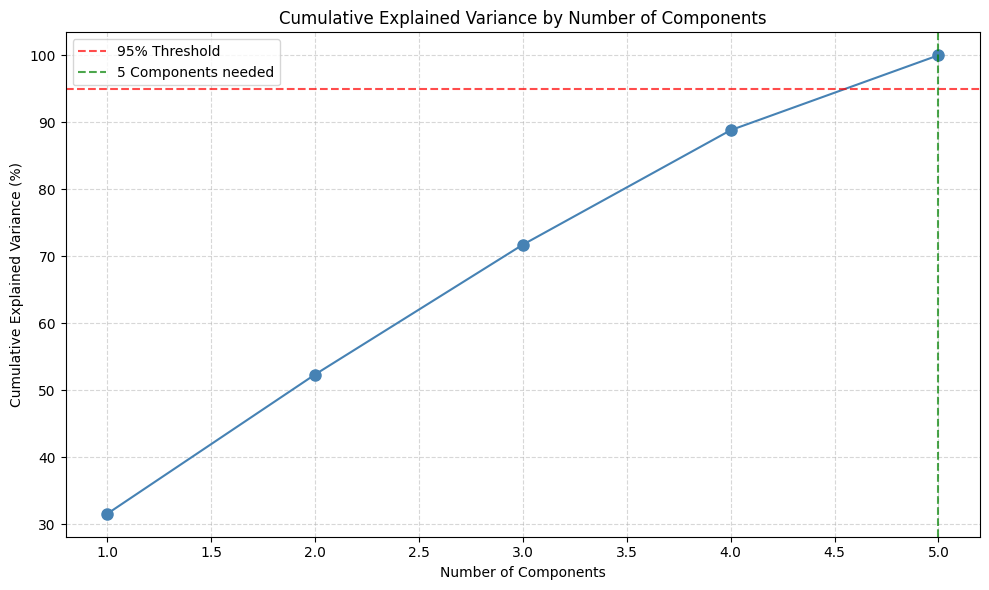

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1),
         cumulative_explained_variance,
         marker='o', linestyle='-', markersize=8, color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% Threshold')
plt.axvline(x=n_components_95, color='green', linestyle='--', alpha=0.7,
            label=f'{n_components_95} Components needed')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Step 10 — Top Eigenvalues



Top three eigenvalues:
  Eigenvalue 1: 1.5786
  Eigenvalue 2: 1.0395
  Eigenvalue 3: 0.9690


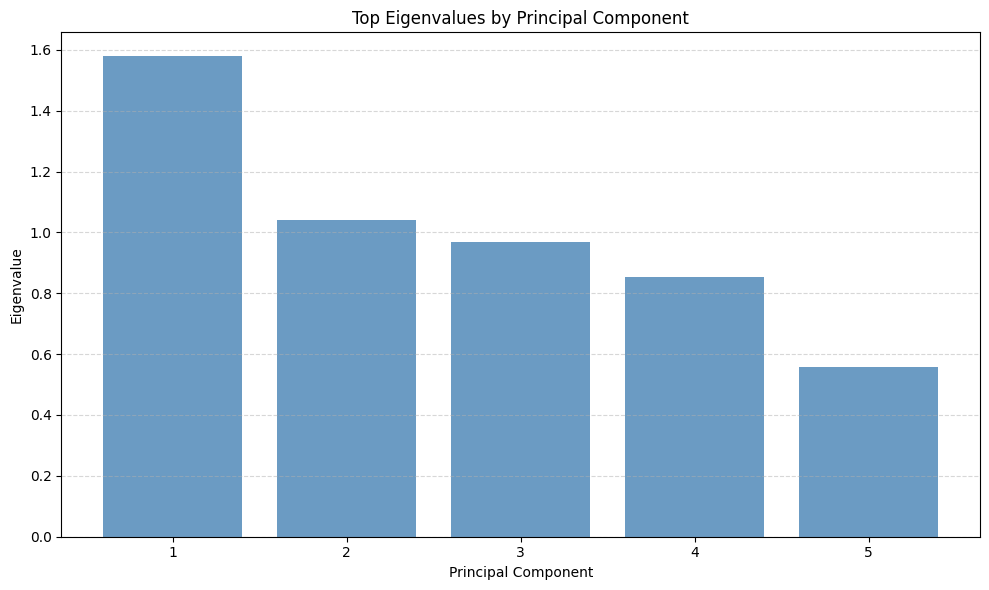

In [11]:
print("Top three eigenvalues:")
top_eigenvalues = pca_full.explained_variance_[:3]
for i, val in enumerate(top_eigenvalues, 1):
    print(f"  Eigenvalue {i}: {val:.4f}")

num_to_plot = min(10, len(pca_full.explained_variance_))
plt.figure(figsize=(10, 6))
plt.bar(range(1, num_to_plot + 1),
        pca_full.explained_variance_[:num_to_plot],
        color='steelblue', alpha=0.8)
plt.title('Top Eigenvalues by Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, num_to_plot + 1))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Step 11 — Feature Contributions (PCA Loadings)



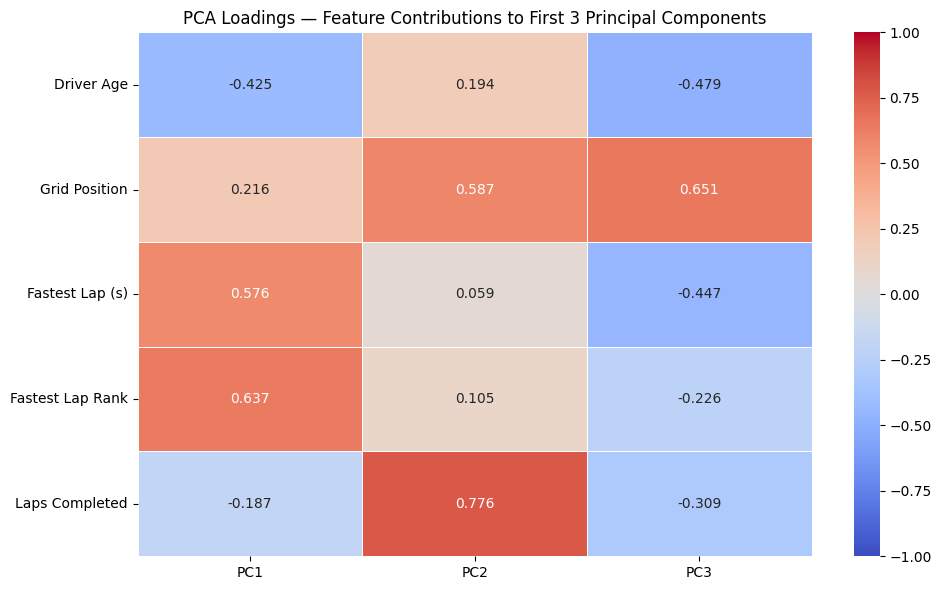


Loadings table:
                    PC1    PC2    PC3
Driver Age       -0.425  0.194 -0.479
Grid Position     0.216  0.587  0.651
Fastest Lap (s)   0.576  0.059 -0.447
Fastest Lap Rank  0.637  0.105 -0.226
Laps Completed   -0.187  0.776 -0.309


In [12]:
component_names = [f'PC{i+1}' for i in range(3)]
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    columns=component_names,
    index=pca_data.columns
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, center=0,
            fmt='.3f', linewidths=0.5)
plt.title('PCA Loadings — Feature Contributions to First 3 Principal Components')
plt.tight_layout()
plt.show()

print("\nLoadings table:")
print(loadings.round(3))